In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

### Up n Clean data

In [89]:
df = pd.read_csv("db/abricate_matrix_HC50.tsv", sep='\t')
df = df.rename(columns={'#FILE': 'Assembly Barcode'})
df['Assembly Barcode'] = df['Assembly Barcode'].str.replace(r'\.result\.fasta$|\.scaffold\.fasta$', '', regex=True)
df.to_csv("out/abricate_matrix_HC50_fixed.csv", index=False, sep='\t')

df_HC = pd.read_csv("out/df_HC.tsv", sep='\t')
df = pd.merge(df, df_HC[['SISTR1 Serovar HC50', 'Assembly Barcode']], on='Assembly Barcode', how='left')
column_to_move = df.pop("SISTR1 Serovar HC50")
df.insert(0, "SISTR1 Serovar HC50", column_to_move)
df = df.drop(columns=['NUM_FOUND', 'Assembly Barcode'])

unique_serovars = df['SISTR1 Serovar HC50'].unique()
for serovar in unique_serovars:
    df[df['SISTR1 Serovar HC50'] == serovar].to_csv(f"out/abricate_matrix_HC50_{serovar.replace(" ", "_")}.tsv", index=False, sep='\t')
df.head(30)

,SISTR1 Serovar HC50,Col(MG828)_1,Col156_1,Col3M_1,Col440II_1,Col440I_1,ColRNAI_1,IncFIA(HI1)_1_HI1,IncFIB(K)_1_Kpn3,IncFIB(S)_1,...,IncI_Gamma_1,IncN_1,IncQ1_1,IncR_1,IncX1_1,IncX3_1,IncX4_2,RepA_1_pKPC-CAV1321,p0111_1,pEC4115_1
0,Typhimurium 293,.,.,.,99.29,100.00;100.00,.,.,.,100.00,...,.,.,.,.,100.00,90.37,.,.,.,.
1,Typhimurium 293,.,.,.,99.29,90.35;100.00;100.00;100.00,.,.,.,100.00,...,.,.,.,.,100.00,.,.,.,.,.
2,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.
3,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.
4,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.
5,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.
6,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.
7,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.
8,Enteritidis 87,.,.,.,.,.,100.00,.,.,100.00,...,.,.,.,.,100.00,90.37,.,.,.,.
9,Infantis 36,.,.,.,.,.,.,.,99.64,.,...,.,.,.,.,.,.,.,.,.,.


### Construct

In [90]:
df_matrix_json = {}
for serovar in df['SISTR1 Serovar HC50'].unique():
    df_matrix_json[serovar] = {resistance_gene: set() for resistance_gene in df.columns[1:]}

for _, row in df.iterrows():
    serovar = row['SISTR1 Serovar HC50']
    for resistance_gene in df.columns[1:]:
        coverage = row[resistance_gene]
        if coverage != '.':
            df_matrix_json[serovar][resistance_gene].add(coverage)

for serovar, genes in df_matrix_json.items():
    for resistance_gene, value in genes.items():
        genes[resistance_gene] = list(value)

matrix_json = {}
for serovar, genes in df_matrix_json.items():
    # Change coverage by int
    # matrix_json[serovar] = {resistance_gene: ' '.join(value) if value else '.' for resistance_gene, value in genes.items()}
    matrix_json[serovar] = {resistance_gene: 1 if value else 0 for resistance_gene, value in genes.items()}

# Export
with open('out/abricate_resistance_gene_matrix.json', 'w') as file:
    json.dump(df_matrix_json, file, indent=4)

In [91]:
matrix = pd.DataFrame.from_dict(matrix_json, orient='index')
matrix

,Col(MG828)_1,Col156_1,Col3M_1,Col440II_1,Col440I_1,ColRNAI_1,IncFIA(HI1)_1_HI1,IncFIB(K)_1_Kpn3,IncFIB(S)_1,IncFIB(pHCM2)_1_pHCM2,...,IncI_Gamma_1,IncN_1,IncQ1_1,IncR_1,IncX1_1,IncX3_1,IncX4_2,RepA_1_pKPC-CAV1321,p0111_1,pEC4115_1
Typhimurium 293,0,0,0,1,1,1,0,0,1,0,...,1,0,1,0,1,1,0,0,0,0
Infantis 36,1,1,0,0,1,1,0,1,0,1,...,0,0,0,0,1,0,1,0,0,1
Enteritidis 87,0,0,0,0,1,1,0,0,1,0,...,0,1,0,0,1,1,0,0,0,0
Agona 29,0,1,1,1,1,1,1,1,0,0,...,0,1,0,0,0,0,0,1,1,0
Newport 938,0,0,0,0,0,1,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
"I 1,4,[5],12:i:- 2",0,1,0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Export Matrix

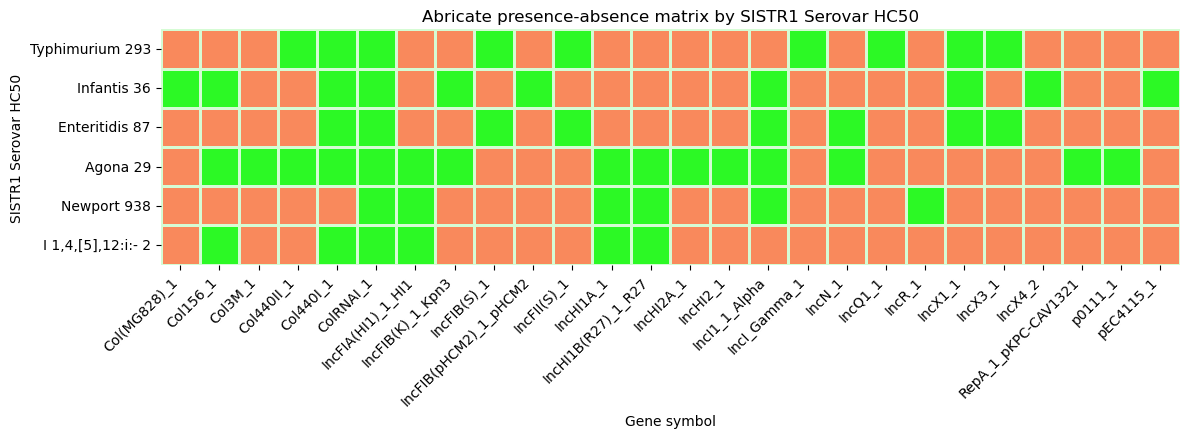

In [92]:
palette = sns.color_palette(["#f9895c", "#2cf925"])

plt.figure(figsize=(12, 4))
ax = sns.heatmap(matrix, cmap=palette, cbar=False, linewidths=1, linecolor='#d5fcd4', square=True)

plt.xticks(rotation=45, ha='right')
plt.title('Abricate presence-absence matrix by SISTR1 Serovar HC50')
plt.xlabel('Gene symbol')
plt.ylabel('SISTR1 Serovar HC50')

plt.tight_layout()
plt.savefig(f'img/HC50_Abricate_resistance_gene_matrix.png', format='png', bbox_inches='tight')
plt.show()